# Thermal Stresses in a Hexagonal Shell

This notebook documents the physics behind the case `sandbox/U_hex_shell` and compares the analytic solution with the z3st result. It reads everything from the case files through `case_params.py`, the same module used by `diagnostics.py`, `non-regression.py` and `plots.py`, so the theory below and the automated check always refer to the same numbers.

**Contents**

1. Problem statement
2. Geometry and local frame
3. Governing equations
4. Thermal solution
5. Mechanical solution: from the free plate to the closed hexagon
6. Symmetries of the stress field
7. Limits of the analytic model: corners, ends, membrane offset
8. Discretisation and how the comparison is made
9. Comparison with z3st along the three axes
10. Non-regression summary
11. References

## 1. Problem statement

A hexagonal steel shell (fuel-assembly wrapper) of outer circumscribed diameter $D$, wall thickness $t$ and height $H$ is heated from the inside and cooled from the outside.

| Surface | Thermal | Mechanical |
|---|---|---|
| inner faces | Neumann: heat flux $q$ entering the wall | traction-free |
| outer faces | Dirichlet: $T = T_o$ | traction-free |
| bottom $z = 0$, top $z = H$ | adiabatic | traction-free (optionally $u_z = 0$ at the bottom) |

There are no body forces and no volumetric heat source. The rigid-body modes of the free body are removed by the solver's null-space option (`remove_rigid_nullspace`). The material (15-15Ti) is linear-elastic and isotropic, with Young's modulus $E$, Poisson's ratio $\nu$, thermal expansion $\alpha$ and stress-free temperature $T_{ref}$. Its conductivity is linear in $T$, $k(T) = k_0 + k_1\,(T - 273.15)$ called fo every T[x] using (`k_1515.py`).

The question is: **what stresses does the temperature gradient through-wall produce?**

In [1]:
import json
import os

import numpy as np

import case_params as cp
from plots import plot_s, plot_xi, plot_z

cp.report()

[case_params] resolved from the case YAML files:
  D            = 0.2
  T_WALL       = 0.0045
  H            = 1.0
  ORIENTATION  = flat
  R_O          = 0.1
  R_I          = 0.09480384757729338
  NF           = 20
  NT           = 3
  NZ           = 40
  E            = 170000000000.0
  NU           = 0.3
  ALPHA        = 1.2e-05
  T_REF        = 300.0
  Q            = 5000.0
  T_O          = 600.0
  DT           = 1.266989 K (T_i - T_o)
  SIGMA_SURF   = 1.8462 MPa


## 2. Geometry and local frame

The vertices lie on circles of radius
$$R_o = \frac{D}{2}, \qquad R_i = R_o - \frac{2t}{\sqrt 3}.$$
The apothem (centre-to-flat distance) of a regular hexagon is $a = R\cos 30^\circ$, so $a_o - a_i = (R_o - R_i)\cos 30^\circ = t$: every inner flat is the outer flat moved inward by exactly $t$, and the two faces of a flat are **parallel**. The side of a regular hexagon equals its circumradius, so a flat is $R_i$ long on the inner face, $R_o$ on the outer face, and $L = (R_i + R_o)/2$ at mid-wall.

There are two possible configurations, based on at which angle $a_0$ the first vertex is: `orientation`: $a_0 = 0$ for `flat`, $\pi/2$ for `vertical`. Flat $m = 0,\dots,5$ has outward normal at
$$\varphi_m = a_0 + \frac{\pi}{6} + m\,\frac{\pi}{3}.$$

Each flat carries a right-handed local frame $(\mathbf n, \mathbf s, \mathbf e_z)$:

* $\xi = \mathbf x\cdot\mathbf n - a_{mid}$: through the wall, $0$ at mid-wall, $\xi \in [-t/2, t/2]$, $-t/2$ on the inner (hot) face;
* $s = \mathbf x\cdot\mathbf s$: along the flat, $0$ at mid-flat, $\pm L/2$ at the corners;
* $z$: along the axis.

Stress components in this frame are $\sigma_{nn} = \mathbf n\cdot\boldsymbol\sigma\,\mathbf n$ (normal to the wall), $\sigma_{ss}$ (hoop, along the flat) and $\sigma_{zz}$ (axial).

The wall is thin: $t/D \approx 0.02$ and $t/L \approx 0.05$, hence the plate theory valid.

## 3. Governing equations

**Heat conduction**, steady state, no source:
$$\nabla\cdot\big(k(T)\,\nabla T\big) = 0, \qquad -k\,\nabla T\cdot\mathbf n_{in} = q \text{ on the inner faces}, \qquad T = T_o \text{ on the outer faces}, \qquad \nabla T\cdot\mathbf e_z = 0 \text{ at } z = 0, H.$$
NB:  Any boundary with no condition in the finite-element formulation is automatically adiabatic. 

**Linear thermo-elasticity** (small strains, one-way coupling: $T$ drives $\mathbf u$, not the reverse):
$$\nabla\cdot\boldsymbol\sigma = \mathbf 0, \qquad \boldsymbol\varepsilon = \tfrac12\left(\nabla\mathbf u + \nabla\mathbf u^{T}\right),$$
$$\boldsymbol\sigma = \lambda\,\mathrm{tr}(\boldsymbol\varepsilon)\,\mathbf I + 2\mu\,\boldsymbol\varepsilon - (3\lambda + 2\mu)\,\alpha\,(T - T_{ref})\,\mathbf I,$$
with $\boldsymbol\sigma\,\mathbf n = \mathbf 0$ on every face (plus $u_z = 0$ at the bottom if the clamp is active).

The thermal strain $\alpha\,(T - T_{ref})\,\mathbf I$ is **isotropic**: a material point wants to expand equally in every direction. Stress appears only where this expansion is incompatible, i.e. where neighbouring points want to expand by different amounts and cannot all do so while the body stays continuous. A uniform temperature change therefore produces no stress in a free body. Only the **non-uniform** part of $T$ matters, and the stress field is set by geometry and compatibility.

### 3.1 Equilibrium: where $\nabla\cdot\boldsymbol\sigma = \mathbf 0$ comes from

**Force balance.** Take any piece of material $V$ with surface $\partial V$. It is loaded by the traction of the surrounding material, $\mathbf t = \boldsymbol\sigma\,\mathbf n$ (Cauchy), and by body forces $\mathbf b$ per unit volume. Newton's second law:
$$\int_{\partial V}\boldsymbol\sigma\,\mathbf n\,dA + \int_V \mathbf b\,dV = \int_V \rho\,\ddot{\mathbf u}\,dV .$$
The divergence theorem turns the surface integral into $\int_V \nabla\cdot\boldsymbol\sigma\,dV$. Since $V$ is arbitrary, the balance holds at every point:
$$\nabla\cdot\boldsymbol\sigma + \mathbf b = \rho\,\ddot{\mathbf u} \qquad \text{(Cauchy's momentum equation).}$$
Here both extra terms vanish:

| term | dropped because |
|---|---|
| $\rho\,\ddot{\mathbf u}$ | quasi-static: $T$ changes slowly compared with elastic wave transit times |
| $\mathbf b$ | no gravity or other body force in the case |

The moment balance of the same piece gives $\boldsymbol\sigma = \boldsymbol\sigma^T$: six independent components.

**Divergence, not gradient.** $\nabla\cdot\boldsymbol\sigma$ is a vector, i.e. three scalar equations $\partial\sigma_{ij}/\partial x_j = 0$, $i = 1,2,3$. It does **not** say the stress is uniform: each row only requires the variations of one traction component to balance. In the local frame $(\mathbf n, \mathbf s, \mathbf e_z)$ of a flat, the $\mathbf n$ row reads
$$\frac{\partial \sigma_{nn}}{\partial \xi} + \frac{\partial \sigma_{ns}}{\partial s} + \frac{\partial \sigma_{nz}}{\partial z} = 0 ,$$
which is the row used in §5.1. $\sigma_{ss}$ and $\sigma_{zz}$ never appear differentiated by $\xi$, so they are free to vary through the wall, and they do (§5.5).

**Closing the problem.** Three equations for six stress components are not enough: equilibrium alone does not fix the stress. Kinematics (strains derived from one continuous $\mathbf u$, i.e. compatibility) and the constitutive law of §3 reduce the unknowns to the three components of $\mathbf u$. Substituting gives the Navier equations with a thermal load:
$$\mu\,\nabla^2\mathbf u + (\lambda+\mu)\,\nabla(\nabla\cdot\mathbf u) = (3\lambda+2\mu)\,\alpha\,\nabla T ,$$
with, on a traction-free face, $\big[\lambda\,\mathrm{tr}(\boldsymbol\varepsilon)\,\mathbf I + 2\mu\,\boldsymbol\varepsilon\big]\mathbf n = (3\lambda+2\mu)\,\alpha\,(T - T_{ref})\,\mathbf n$.

The temperature acts as an equivalent body force $-(3\lambda+2\mu)\,\alpha\,\nabla T$ plus an equivalent pressure on the boundary (Duhamel–Neumann analogy). For a uniform $T$ the body force vanishes, and the boundary pressure is absorbed by the free expansion $\mathbf u = \alpha\,(T - T_{ref})\,\mathbf x$, which gives $\boldsymbol\sigma = \mathbf 0$. Only $\nabla T$ can produce stress, as stated in §3.

### 3.2 Weak form and natural boundary conditions

z3st does not solve the equations above point by point. It solves their **weak form**: multiply by a test function, integrate over the domain $\Omega$, and integrate by parts. The boundary term that integration by parts creates is where the boundary conditions enter.

**Heat.** With test function $w$ ($w = 0$ on Dirichlet faces) and outward normal $\mathbf n$:
$$\int_\Omega k(T)\,\nabla T\cdot\nabla w\,dx = -\int_{\partial\Omega} (\mathbf q\cdot\mathbf n)\,w\,ds, \qquad \mathbf q = -k\,\nabla T .$$
The right-hand side is assembled only on the faces listed in `boundary_conditions.yaml`. The `flux` value is the outward normal flux $\mathbf q\cdot\mathbf n$, so $-5000$ W/m² on `inner` is heat **entering** the wall. On every face with no card the term is simply absent, which is the same as imposing $\mathbf q\cdot\mathbf n = 0$: adiabatic. This is the *natural* boundary condition of the formulation, and it is why the top and bottom are adiabatic without being declared.

**Mechanics.** With test function $\mathbf v$:
$$\int_\Omega \boldsymbol\sigma(\mathbf u) : \boldsymbol\varepsilon(\mathbf v)\,dx = \int_{\partial\Omega} \mathbf t\cdot\mathbf v\,ds .$$
With the `mechanical:` block commented out, no traction is applied anywhere: $\mathbf t = \mathbf 0$ on every face, the natural condition, i.e. traction-free.

**Consequence: the rigid-body null space.** The left-hand side vanishes for any rigid motion $\mathbf u = \mathbf a + \boldsymbol\omega\times\mathbf x$ (three translations, three rotations), because these produce no strain. With no displacement condition anywhere, $\mathbf u$ is defined only up to such a motion and the stiffness matrix is singular. `remove_rigid_nullspace` removes these six modes; the stress is unaffected. With the optional clamp $u_z = 0$ at the bottom, the axial translation and the two tilts are fixed by the boundary instead.

## 4. Thermal solution

### 4.1 Reduction to one dimension

On a flat, the inner and outer faces are parallel and carry uniform conditions, and the top and bottom are adiabatic. A field depending on $\xi$ alone, $T = T(\xi)$, satisfies the heat equation and **all** the boundary conditions of that flat exactly. The only place it fails is the corners, where the wall turns by $60^\circ$ and heat flows in two dimensions. Away from the corners the temperature is one-dimensional:
$$\frac{d}{d\xi}\left(k(T)\,\frac{dT}{d\xi}\right) = 0 \quad\Rightarrow\quad -k(T)\,\frac{dT}{d\xi} = q = \text{const}.$$

### 4.2 Kirchhoff transform

Define $\Theta(T) = \int_{T_o}^{T} k(\tau)\,d\tau$. Then $d\Theta/d\xi = -q$, so $\Theta$ is linear even though $T$ is not:
$$\Theta\big(T(\xi)\big) = q\left(\frac t2 - \xi\right).$$

**Wall drop.** At the inner face, $\Theta(T_i) = q\,t$. For a linear $k$, the integral equals the midpoint value times the interval, **exactly**:
$$k\!\left(\frac{T_i + T_o}{2}\right)(T_i - T_o) = q\,t .$$
This is a quadratic in $\Delta T = T_i - T_o$; `case_params.wall_drop()` solves it by fixed-point iteration.

**Profile.** Inverting $\Theta$, with $k_o = k(T_o)$:
$$T(\xi) = T_o + \frac{-k_o + \sqrt{k_o^2 + 2k_1\,q\,(t/2 - \xi)}}{k_1}.$$
Expanding the square root, $T$ deviates from the straight line between $T_i$ and $T_o$ by a parabola whose maximum, at mid-wall, is
$$\max|T - T_{lin}| \simeq \frac{k_1\,\Delta T}{8\,\bar k}\,\Delta T \approx 10^{-4}\,\Delta T .$$
In what follows the profile is therefore **linear**:
$$T(\xi) = \bar T - \Delta T\,\frac{\xi}{t}, \qquad \bar T = \frac1t\int T\,d\xi .$$

### 4.3 How z3st reaches this solution

The case runs a steady problem four times (`time: [0, 3]`, `n_steps: 4`). Each step evaluates $k(T)$ on the **previous** step's temperature, so the steps form a fixed-point (Picard) iteration on $k$. `history.csv` shows $\Delta T$ change between steps 0 and 1 and then stay constant; the last-step change is one of the checked metrics.

In [2]:
xi = np.linspace(-cp.T_WALL / 2, cp.T_WALL / 2, 201)
T_exact = cp.temperature(xi)
T_lin = cp.T_O + cp.DT * (0.5 - xi / cp.T_WALL)
print(f"Delta T = T_i - T_o        : {cp.DT:.6f} K")
print(f"T_i                        : {cp.T_I:.6f} K")
print(f"max |T_exact - T_linear|   : {np.abs(T_exact - T_lin).max():.2e} K "
      f"({np.abs(T_exact - T_lin).max() / cp.DT:.1e} of Delta T)")

Delta T = T_i - T_o        : 1.266989 K
T_i                        : 601.266989 K
max |T_exact - T_linear|   : 1.31e-04 K (1.0e-04 of Delta T)


## 5. Mechanical solution: from the free plate to the closed hexagon

### 5.1 Plate hypotheses and zero stress across the thickness

Take one flat as a plate of thickness $t$. Its faces $\xi = \pm t/2$ are traction-free: $\sigma_{nn} = \sigma_{ns} = \sigma_{nz} = 0$ there. The normal equilibrium equation is
$$\frac{\partial \sigma_{nn}}{\partial \xi} + \frac{\partial \sigma_{ns}}{\partial s} + \frac{\partial \sigma_{nz}}{\partial z} = 0 .$$
Away from corners and ends nothing varies with $s$ or $z$, so $\partial\sigma_{nn}/\partial\xi = 0$. With $\sigma_{nn} = 0$ on both faces, this gives
$$\sigma_{nn}(\xi) \equiv 0 \quad\text{through the whole thickness.}$$
This is the **plane-stress** condition of plate theory, here exact rather than approximate. It follows from equilibrium, traction-free faces and invariance in $s$ and $z$ alone, so it holds for any profile $T(\xi)$, linear or not, and for any in-plane restraint: these set $\sigma_{ss}$ and $\sigma_{zz}$, not $\sigma_{nn}$.

With the **Kirchhoff–Love** hypothesis (normals to the mid-surface stay straight and normal), the in-plane strains are linear in $\xi$:
$$\varepsilon_{ss}(\xi) = \varepsilon^0_s - \kappa_s\,\xi, \qquad \varepsilon_{zz}(\xi) = \varepsilon^0_z - \kappa_z\,\xi,$$
with $\varepsilon^0$ the mid-wall (membrane) strains and $\kappa$ the curvatures. The stretch of the normal, $\varepsilon_{nn}$, does not enter $\varepsilon_{ss}$ and $\varepsilon_{zz}$; it follows from $\sigma_{nn} = 0$ (§5.6).

### 5.2 Constitutive law with $\sigma_{nn} = 0$

Eliminating $\varepsilon_{nn}$ with $\sigma_{nn} = 0$ gives the biaxial Hooke law with thermal strain $\alpha\,\Delta T(\xi)$, $\Delta T = T - T_{ref}$:
$$\sigma_{ss} = \frac{E}{1-\nu^2}\Big[(\varepsilon_{ss} - \alpha\Delta T) + \nu\,(\varepsilon_{zz} - \alpha\Delta T)\Big],$$
$$\sigma_{zz} = \frac{E}{1-\nu^2}\Big[(\varepsilon_{zz} - \alpha\Delta T) + \nu\,(\varepsilon_{ss} - \alpha\Delta T)\Big].$$
The four unknowns $\varepsilon^0_s, \varepsilon^0_z, \kappa_s, \kappa_z$ follow from the resultants per unit length,
$$N_\beta = \int_{-t/2}^{t/2}\sigma_{\beta\beta}\,d\xi, \qquad M_\beta = \int_{-t/2}^{t/2}\sigma_{\beta\beta}\,\xi\,d\xi, \qquad \beta = s, z,$$
together with what the rest of the structure imposes on the flat.

### 5.3 The free plate (the original exercise): zero stress

A free plate carries no resultants: $N_s = N_z = 0$ and $M_s = M_z = 0$. The equations are symmetric in $s \leftrightarrow z$, so $\varepsilon^0_s = \varepsilon^0_z = \varepsilon^0$, $\kappa_s = \kappa_z = \kappa$ and
$$\sigma(\xi) = \frac{E}{1-\nu}\Big[\varepsilon^0 - \kappa\,\xi - \alpha\,\Delta T(\xi)\Big].$$
$N = 0$ gives $\varepsilon^0 = \alpha(\bar T - T_{ref})$, and $M = 0$ gives $\kappa = -\dfrac{12\,\alpha}{t^3}\displaystyle\int T\,\xi\,d\xi$. Hence
$$\sigma(\xi) = \frac{\alpha E}{1-\nu}\left[\underbrace{\bar T}_{\text{mean}} + \underbrace{\frac{12\,\xi}{t^3}\int_{-t/2}^{t/2} T(\xi')\,\xi'\,d\xi'}_{\text{bending}} - T(\xi)\right].$$
For the **linear** profile of §4, $\int T\,\xi\,d\xi = -\Delta T\,t^2/12$, so the bending term equals $T(\xi) - \bar T$ exactly and
$$\sigma(\xi) \equiv 0 .$$
The free plate expands by $\alpha(\bar T - T_{ref})$ and curves by $\kappa = \alpha\,\Delta T/t$ (convex towards the hot side). Its free thermal strain is linear in $\xi$, so it is already compatible: **a linear gradient in a free plate produces no stress.** Only the non-linear part of $T$ would.

### 5.4 The closed hexagon: bending is suppressed

The flats are not free: they are joined at the corners into a closed tube. This adds constraints in both in-plane directions.

**Hoop direction ($\kappa_s = 0$).** Cut the section along two mirror planes of the hexagon, one through mid-flat and one through the adjacent corner. The piece between them is $1/12$ of the section.

* By mirror symmetry the transverse shear force vanishes on both cuts.
* The piece carries no external load. The normal forces on its two cuts act in directions $30^\circ$ apart, and two non-parallel forces can only balance if both are zero: $N_s = 0$.
* With $V = dM_s/ds = 0$, the hoop moment $M_s$ is the same everywhere around the section. It is the only unknown internal force.
* Compatibility: a mirror plane cannot rotate, so the total rotation across the piece is zero:
$$\int_{\text{piece}}\left(\kappa_T + \frac{M_s}{D_b}\right) ds = 0,$$
with $\kappa_T = \alpha\Delta T/t$ the free thermal curvature and $D_b$ the bending stiffness.

If $\kappa_T$ were the same all round the section, this would give $\kappa_s = \kappa_T + M_s/D_b = 0$ everywhere. On the flats it is the same; only the corners, a small fraction of the perimeter, differ. So on the flats $\kappa_s \simeq 0$. Geometrically: if every flat curved outward, the six flats could not stay joined at $120^\circ$ corners; the closed ring forbids the curvature.

**Axial direction ($\kappa_z = 0$).** Away from the ends ($H/D = 5$), the tube is in generalized plane strain: plane cross-sections stay plane, $\varepsilon_{zz} = A + Bx + Cy$. The temperature field has the six-fold symmetry of the section, so the section has no reason to tilt one way rather than another: $B = C = 0$. On a flat, $\varepsilon_{zz} = A$ is uniform: $\kappa_z = 0$. Geometrically: a flat cannot bow in $z$ without the whole tube bending, and a symmetric section does not bend.

**Membrane strains.** $N_s = 0$ (above). $N_z = 0$ because the ends are free. Strictly, $N_z = 0$ holds for the whole cross-section, not for each flat separately (see §7.3).

### 5.5 Result

With $\kappa_s = \kappa_z = 0$ and $N_s = N_z = 0$: $\varepsilon^0_s = \varepsilon^0_z = \alpha(\bar T - T_{ref})$, and the biaxial law gives
$$\boxed{\;\sigma_{nn} = 0, \qquad \sigma_{ss}(\xi) = \sigma_{zz}(\xi) = \frac{\alpha E}{1-\nu}\big(\bar T - T(\xi)\big) = \frac{\alpha E}{1-\nu}\,\Delta T\,\frac{\xi}{t}\;}$$

This is the free-plate formula with the bending term removed. The stress is exactly the bending stress the free plate would have relieved, now locked in by the closed section. Surface values:
$$\sigma_{ss} = \sigma_{zz} = \mp\frac{\alpha E\,\Delta T}{2(1-\nu)} \quad\text{at } \xi = \mp\frac t2 \quad\text{(compressive inside, tensile outside).}$$
The same result holds for a thin-walled cylinder (Timoshenko & Goodier); the hexagon reaches it with flat walls because the closed section, not the curvature, provides the restraint.

**What does not enter.**
* $T_{ref}$: the uniform part of the expansion, $\alpha(\bar T - T_{ref})$, dilates the whole section uniformly and is free.
* $T_{initial}$: only the starting guess of the thermal problem.
* `orientation`: rotating the hexagon only relabels the flats.
* The bottom clamp $u_z = 0$: compatible with $\varepsilon_{zz} = A$ (see §6.4).

### 5.6 Through-thickness strain

$\sigma_{nn} = 0$ means that the change of thickness is unresisted, not that it is zero. Inverting Hooke's law,
$$\varepsilon_{nn} = \frac1E\big[\sigma_{nn} - \nu\,(\sigma_{ss} + \sigma_{zz})\big] + \alpha\,(T - T_{ref}) = \alpha\,(T - T_{ref}) - \frac{\nu}{E}\,(\sigma_{ss} + \sigma_{zz}),$$
and with the stresses of §5.5:
$$\boxed{\;\varepsilon_{nn}(\xi) = \alpha\,(\bar T - T_{ref}) + \frac{1+\nu}{1-\nu}\,\alpha\,\big(T(\xi) - \bar T\big)\;}$$

* **Uniform part**, $\alpha(\bar T - T_{ref})$: the free thermal expansion of the wall at its mean temperature.
* **Odd part**: the hot inner side, in in-plane compression, thickens more by the Poisson effect; the cool outer side, in tension, thickens less. The factor $(1+\nu)/(1-\nu)$ combines the thermal and the Poisson contributions.

The odd part integrates to zero across the wall, so the change of thickness is set by the mean temperature alone:
$$\Delta t = \int_{-t/2}^{t/2}\varepsilon_{nn}\,d\xi = \alpha\,(\bar T - T_{ref})\,t .$$

In [3]:
print(f"alpha E / (1 - nu)          : {cp.C_TH / 1e6:.4f} MPa/K")
print(f"surface stress               : -/+ {cp.SIGMA_SURF / 1e6:.4f} MPa (inner / outer)")
print(f"restraint moment per length  : M = {cp.C_TH * cp.DT * cp.T_WALL**2 / 12:.4f} N")

alpha E / (1 - nu)          : 2.9143 MPa/K
surface stress               : -/+ 1.8462 MPa (inner / outer)
restraint moment per length  : M = 6.2309 N


In [ ]:
T_bar = cp.T_O + cp.DT / 2
eps_uniform = cp.ALPHA * (T_bar - cp.T_REF)
eps_odd = (1 + cp.NU) / (1 - cp.NU) * cp.ALPHA * cp.DT / 2
print(f"eps_nn uniform part          : {eps_uniform:.4e}")
print(f"eps_nn odd part at the faces : +/- {eps_odd:.4e} (inner / outer)")
print(f"thickness change             : Delta t = {eps_uniform * cp.T_WALL * 1e6:.2f} um")

## 6. Symmetries of the stress field

The result has four symmetries. Each one has a physical cause, and each is checked by the non-regression.

### 6.1 $\sigma_{ss} = \sigma_{zz}$: equi-biaxial stress

Three ingredients make the two in-plane directions equivalent:

1. the thermal strain $\alpha\Delta T\,\mathbf I$ is the same in every direction;
2. the material is isotropic, so the biaxial law (§5.2) is unchanged when $s$ and $z$ are swapped;
3. the constraints are the same in both directions: no curvature ($\kappa_s = \kappa_z = 0$) and no membrane force ($N_s = N_z = 0$).

The equations for $(\varepsilon_{ss}, \sigma_{ss})$ and $(\varepsilon_{zz}, \sigma_{zz})$ are therefore identical, and so are their solutions. The factor $1/(1-\nu)$ comes from this: with $\varepsilon_{ss} = \varepsilon_{zz}$, the Poisson contraction from one direction adds to the restraint in the other, $E/(1-\nu^2)\cdot(1+\nu) = E/(1-\nu)$.

*Checked by* `sigma_zz_xi_L2` (σ_zz against the same analytic profile as σ_ss).

### 6.2 Odd in $\xi$: equal and opposite on the two faces

$\sigma \propto \bar T - T(\xi)$, and for a linear profile $T - \bar T$ is an odd function of $\xi$. Hence
$$\sigma(-\xi) = -\sigma(\xi), \qquad \sigma(0) = 0 .$$
Physically, the hot inner fibres want to expand more than the mean, are held back, and go into compression; the cool outer fibres are stretched by the same amount. Two consequences follow:
* $N = \int\sigma\,d\xi = 0$ automatically, consistent with no external load;
* $M = \int\sigma\,\xi\,d\xi = \frac{\alpha E}{1-\nu}\,\frac{\Delta T\,t^2}{12} \neq 0$. This is the moment the closed ring applies to keep the flat straight.

*Checked by* `sigma_ss_xi_odd` ($|\sigma(-t/3) + \sigma(t/3)| / |\sigma(t/3)|$) and `sigma_ss_xi_L2`.

### 6.3 Six-fold symmetry ($D_6$): the same on every flat, even in $s$

The geometry, the boundary conditions and the material are unchanged by the twelve symmetries of the regular hexagon (six rotations by $60^\circ$ and six mirrors). Because the solution of a linear problem is unique, it must have the same symmetries:
* **rotations**: all six flats carry the same fields;
* **mirror through mid-flat**: every field is even in $s$, $\sigma(s) = \sigma(-s)$, and the shear force vanishes at $s = 0$ (used in §5.4).

*Checked by* `sigma_ss_flat_spread`, the spread of $\sigma_{ss}$ over the six flats (the solver's own symmetry, about $10^{-8}$ here).

### 6.4 Mirror in $z$: even about mid-height (free–free) or the bottom (clamped)

* **Free–free** (current case): the problem is unchanged by $z \to H - z$, so the fields are even about $z = H/2$, and the two ends are disturbed identically.
* **Clamp $u_z = 0$ at the bottom**: on a face with zero normal displacement and zero shear traction, the conditions are exactly those of a mirror plane. The shell then behaves as the lower half of a free tube of length $2H$ mirrored about $z = 0$: no disturbance at the bottom, a free-end disturbance at the top only.

*Checked by* `sigma_ss_bottom_ratio` and `sigma_ss_top_ratio` (equal for free–free) and the far-field check `sigma_ss_z_window`.

## 7. Limits of the analytic model

The slab solution is exact only in the **far field**, away from three kinds of disturbance.

### 7.1 Corners

At a corner the wall turns by $60^\circ$. Measured along the corner bisector it is $2t/\sqrt3$ thick, and heat spreads into a wedge whose outer face is longer than its inner face. The conduction path is wider, the thermal resistance lower, and the inner corner runs **cooler** than the flats (`T_inner_corner_drop_K` ≈ 0.33 K, about 26 % of $\Delta T$). Mechanically, the corner is a stiff joint with its own temperature, so the hoop stress near it departs from the slab value (`sigma_ss_corner_ratio` ≈ 0.72 in the outer cell layer). The thermal disturbance dies out within about two cells (≈ $2t$) of the corner. The mechanical one decays gradually along the flat, which is why the $s$ check uses the central half, $|s| < L/4$, where the deviation stays below 1 %.

### 7.2 Free ends

At a free end the axial stress must vanish on the end face, $\sigma_{zz}(z = H) = 0$, while in the far field $\sigma_{zz}$ is the locked-in bending stress. Removing it is equivalent to applying an opposite edge moment, which the shell carries over an **end zone**:

* $\sigma_{ss}$ at the end cell rises to about 1.16 times the far-field value (`sigma_ss_top_ratio`), then oscillates with decaying amplitude. This is the response of a shell to an edge moment. For a thin cylinder the classical end factor is about 1.25 at the surface (Timoshenko & Woinowsky-Krieger); here the value is read at the cell centre, 12.5 mm from the edge and $t/3$ from mid-wall, so it is not directly comparable.
* The end zone reaches about 0.2 m ($\approx D$) along the axis. For a cylinder of the same size the decay length would be $\sqrt{a\,t}/[3(1-\nu^2)]^{1/4} \approx 1.5$ cm. The flat walls of the hexagon have no hoop curvature, so they cannot carry the edge moment by hoop membrane action as a cylinder does. They carry it by plate bending between the corners, over a length set by the flat width, so the disturbance reaches much further.
* The cells are $h_z = 25$ mm tall, much more than $t$. The thin layer next to the end face where $\sigma_{zz} \to 0$ (of order $t$ thick) is not resolved; the end-cell values are averages over that layer.

The $z$ check therefore uses the central half of the height.

### 7.3 Axial membrane offset

$N_z = 0$ is a condition on the **whole** cross-section, $\int_A \sigma_{zz}\,dA = 0$. The corners, with their different temperature and stiffness, carry part of the axial force, and the flats balance it with a small uniform $\sigma_{zz}$: −0.047 MPa here (about 4 % of the layer value), visible as a shift of the $\sigma_{zz}$ points. The slab model cannot predict it. It is recorded as a tracked value (`sigma_zz_offset_MPa`), and $\sigma_{zz}$ is checked with it removed. $\sigma_{ss}$ has no such offset, because $N_s = 0$ holds on every cut (§5.4).

### 7.4 Residual $\sigma_{nn}$

The computed $\sigma_{nn}$ is about −6.5 kPa, 0.36 % of the surface stress (`sigma_nn_xi_max`). It is a discretisation effect of the low-order hexahedra; the exact value is zero (§5.1).

## 8. Discretisation and how the comparison is made

**Mesh** (`3d/mesh.geo`, transfinite): $n_f$ hexahedra along each flat, $n_t$ through the wall, $n_z$ along the axis, all read from `3d/geometry.yaml`. Because the inner and outer flats are parallel, the cell centres of wall layer $j$ lie exactly at
$$\xi_j = -\frac t2 + \left(j + \tfrac12\right)\frac{t}{n_t},$$
which `case_params.check_consistency` uses to detect a `geometry.yaml` that does not match the solved mesh.

**Fields.** The temperature is continuous and piecewise trilinear (nodal values); it reproduces a linear profile exactly. The stress is exported cell-wise (DG0): one value per cell, the stress evaluated at the cell centre. For a stress linear in $\xi$, the cell-centre value equals the exact value at $\xi_j$, so the comparison is free of averaging error. With $n_t = 3$ the analytic values at the centres are $\mp\tfrac23$ of the surface stress and $0$.

**Two read-outs, one set of definitions:**

| | when | reads | used by |
|---|---|---|---|
| `diagnostics.py` | during the run, every step | the stress (interpolated into DG0) and $T$ at the stations of `case_params.STATIONS`, on all six flats | `history.csv` → `non-regression.py` |
| `case_params.local_fields` | after the run | all cells and nodes of the last step in `fields.xdmf` | `plots.py`, this notebook |

Both rotate the stress into $(\mathbf n, \mathbf s, \mathbf e_z)$ with the same `flat_axes` / `flat_frame` geometry and compare against the same `sigma_wall` and `temperature` functions.

**Lines.** Each comparison fixes two coordinates and runs along the third:

| line | fixed | band | far-field window checked |
|---|---|---|---|
| $\xi$ | $s = 0$, $z = H/2$ | $\pm 0.75\,h_s$, $\pm 0.75\,h_z$ | whole wall |
| $s$ | $z = H/2$ | $\pm 0.75\,h_z$ | $\lvert s\rvert < L/4$ |
| $z$ | $s = 0$ | $\pm 0.75\,h_s$ | $\lvert z - H/2\rvert < H/4$ |

with $h_s = L/n_f$ and $h_z = H/n_z$. A band of $0.75$ element on each side holds the one (odd count) or two (even count) rows of cells nearest the line and shrinks with refinement.

## 9. Comparison with z3st along the three axes

The figures below are produced by `plots.py` (the same functions write `output/profile_{xi,s,z}.png` in the Allrun). The six flats and the rows inside the band collapse onto one curve per cell layer.

In [4]:
nodes, cells = cp.local_fields()
problems = cp.check_consistency(cells)
print("consistency:", "OK" if not problems else problems)

consistency: OK


### 9.1 Through the wall ($\xi$), mid-flat, mid-height

The temperature follows the Kirchhoff profile; the stresses fall on the analytic line, with $\sigma_{nn} \approx 0$. $\sigma_{zz}$ sits slightly below $\sigma_{ss}$ by the uniform offset of §7.3.

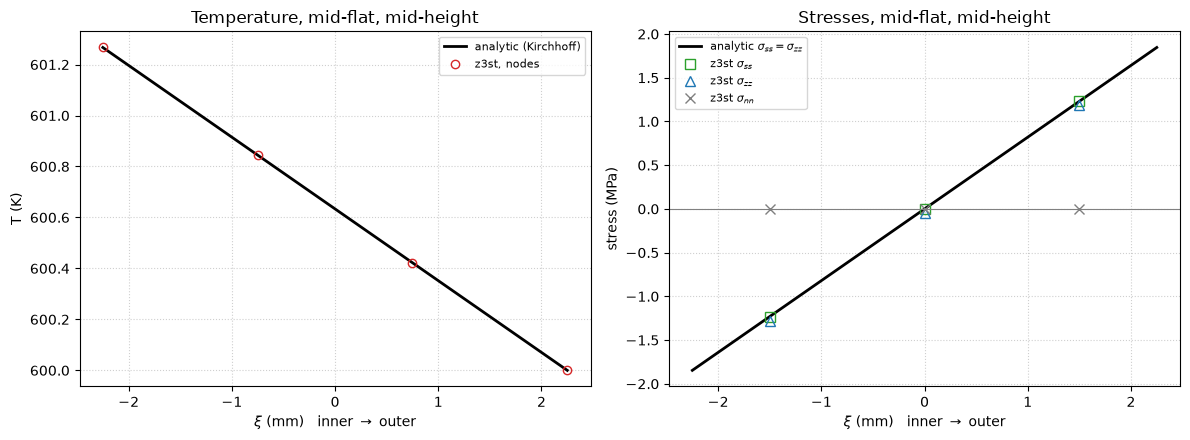

In [5]:
fig = plot_xi(nodes, cells)

### 9.2 Along the flat ($s$), mid-height

Flat profiles across the central half (shaded- away from corners), as §5 predicts. The cooler inner corner (§7.1) and the corner stress disturbance appear at the ends of the flat.

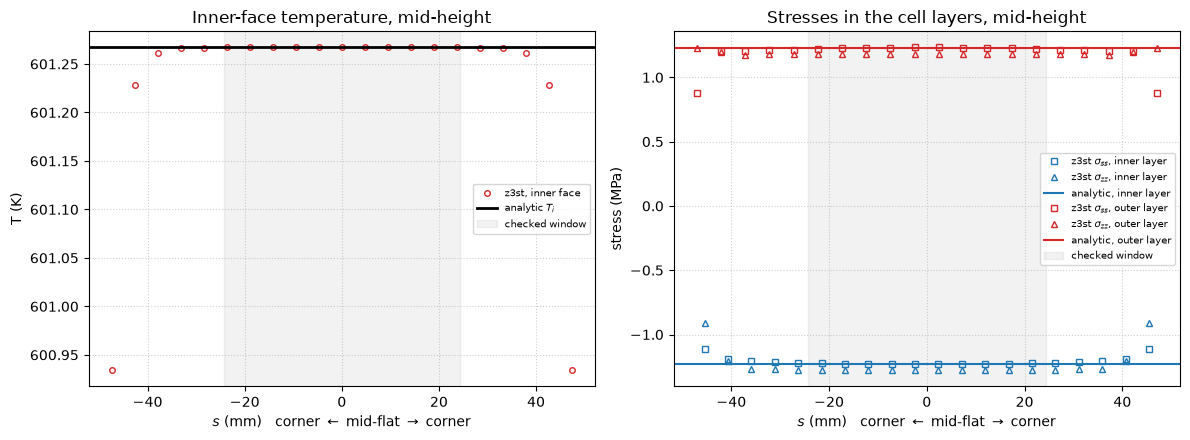

In [6]:
fig = plot_s(nodes, cells)

### 9.3 Along the axis ($z$), mid-flat

The temperature is uniform over the height to round-off (adiabatic ends). The stresses are uniform in the central half and show the decaying end-zone oscillation at both free ends, symmetric about mid-height (§6.4, §7.2).

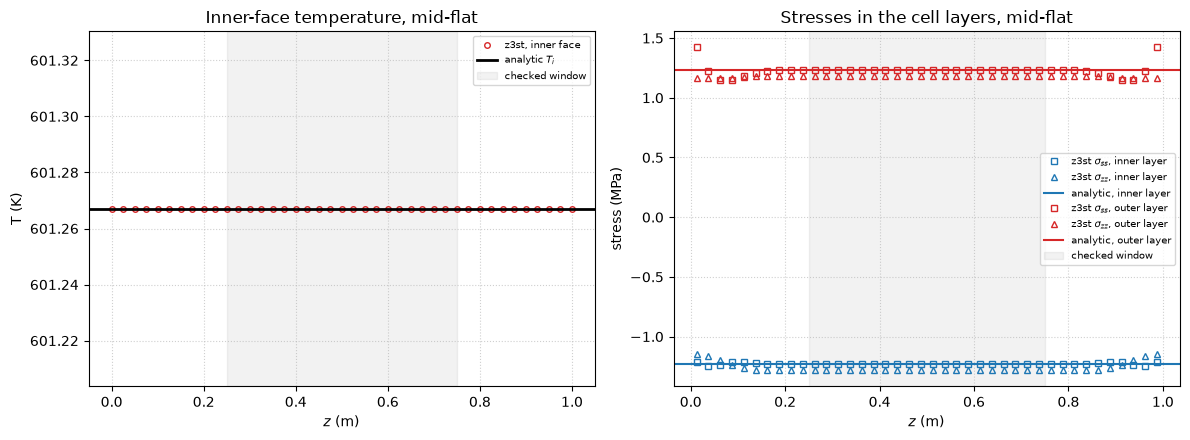

In [7]:
fig = plot_z(nodes, cells)

## 10. Non-regression summary

`non-regression.py` reads the last row of `output/history.csv` and writes `output/non-regression.json`. Metrics with a closed form are checked against the 1 % tolerance. Tracked metrics (corner and end values, the axial offset) have no closed form; they always pass the analytic gate and are protected by the gold file alone, so a gold created from a wrong run would protect the wrong values.

In [8]:
path = os.path.join(cp.HERE, "output", "non-regression.json")
with open(path) as f:
    nr = json.load(f)
print(f"{'metric':<28} {'numerical':>13} {'reference':>13} {'rel. error':>11}  status")
for key, r in nr["results"].items():
    print(f"{key:<28} {r['numerical']:>13.6g} {r['reference']:>13.6g} {r['rel_error']:>11.2e}  {r['status']}")
print("\nsummary:", nr["summary"])

metric                           numerical     reference  rel. error  status
wall_dT_K                          1.26699       1.26699    3.24e-07  PASS
wall_dT_last_step_change                 0             0    0.00e+00  PASS
sigma_ss_xi_L2                  0.00124545             0    1.25e-03  PASS
sigma_zz_xi_L2                 0.000428673             0    4.29e-04  PASS
sigma_nn_xi_max                 0.00357115             0    3.57e-03  PASS
sigma_ss_xi_odd                9.98068e-05             0    9.98e-05  PASS
sigma_ss_flat_spread           8.03059e-09             0    8.03e-09  PASS
sigma_zz_offset_MPa              -0.047407     -0.047407    0.00e+00  PASS
sigma_ss_s_window              1.22144e+06   1.23079e+06    7.60e-03  PASS
sigma_ss_corner_ratio             0.715941      0.715941    0.00e+00  PASS
T_inner_corner_drop_K             0.332951      0.332951    0.00e+00  PASS
T_inner_z_max                            0             0    0.00e+00  PASS
sigma_ss_z_window      

## 11. References

* S. P. Timoshenko, J. N. Goodier, *Theory of Elasticity*, McGraw-Hill: thermal stresses in plates and thin-walled cylinders.
* S. P. Timoshenko, S. Woinowsky-Krieger, *Theory of Plates and Shells*, McGraw-Hill: thermal bending of plates; edge effects in cylindrical shells.
* B. A. Boley, J. H. Weiner, *Theory of Thermal Stresses*, Wiley: Kirchhoff transform for temperature-dependent conductivity.